In [1]:
import pandas as pd

import protfasta
import numpy as np
import requests
import re
import warnings
warnings.filterwarnings("ignore")
import glob


from Bio import AlignIO
import matplotlib.pyplot as plt
from Bio.Align import AlignInfo

from Bio.Align import MultipleSeqAlignment
from Bio.SeqRecord import SeqRecord
from Bio.Seq import Seq


import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import metapredict

In [38]:
import os
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import protfasta
import statsmodels.api as sm

from Bio.PDB import PDBParser
from Bio.PDB.DSSP import DSSP

# from Bio.PDB import PDBParser
# from Bio.PDB.DSSP import DSSP
# import pandas as pd
# import seaborn as sns
# import numpy as np
# import matplotlib.pyplot as plt
import itertools
# import matplotlib.patches as patches


Downloaded FOS and JUn alignments from base_url = "https://genome.senckenberg.de/download/TOGA/human_hg38_reference/MultipleCodonAlignments/" 6/10/25


In [5]:
def return_percent_identity_df(file_path):
    gene_name = file_path.split(".")[-2]

    df = protfasta.read_fasta(file_path, invalid_sequence_action = 'convert') #Convert - to ""
    df = pd.DataFrame({"id" : df.keys(), "nt_seq" : df.values()})

    # Translate sequences
    df["prot_seq"] = [str(Seq(_).translate())[:-1] for _ in df["nt_seq"]]

    # Save protein sequences in dictionary
    prot_dict = dict(zip(df["id"], df["prot_seq"]))
    protfasta.write_fasta(prot_dict, "../data/" + gene_name + "_prot_fasta.fasta")

    # Generate alignment
    os.system("mafft --auto --quiet ../data/" + gene_name + "_prot_fasta.fasta > ../output/" + gene_name + "_prot_alignment.fasta")

    # Calculate percent identity

    # Read alignment
    alignment = AlignIO.read("../output/" + gene_name + "_prot_alignment.fasta", "fasta")
    percent_identities = []

    # Parse through alignment, save reference
    for record in alignment:
        if "REFERENCE" in record.id:
            reference_seq = record.seq

    percent_identities = []
    positions = []

    # Iterate over each position in the alignment where ref_AA is not a gap
    for i in range(alignment.get_alignment_length()):
        ref_AA = reference_seq[i]

        if ref_AA != "-":
            # Get the column (position) for all sequences
            column = alignment[:, i]
        
            # Calculating percent identity
            count = column.count(ref_AA)
            percent_identity = 100 * count / len(column)
        
            # AAs.append(ref_AA)
            percent_identities.append(percent_identity)
            positions.append(ref_AA)
        
    percent_identities_df = pd.DataFrame({"percent_identity" : percent_identities, "pos" : positions})
    return percent_identities_df

    #percent_identities_df.to_csv("../data/zoonomia_toga_mca_all_TFs/prot_alignment_percent_identities_for_vis/" + gene)
    #display(percent_identities_df)


In [7]:
fos_percent_identities_df = return_percent_identity_df("../data/ENST00000303562.FOS.fasta")
fos_percent_identities_df

,percent_identity,pos
0,94.117647,M
1,94.320487,M
2,93.914807,F
3,93.914807,S
4,89.452333,G
...,...,...
375,97.160243,T
376,97.160243,L
377,97.160243,L
378,97.160243,A


In [8]:
jun_percent_identities_df = return_percent_identity_df("../data/ENST00000371222.JUN.fasta")
jun_percent_identities_df

,percent_identity,pos
0,99.765808,M
1,94.379391,T
2,98.594848,A
3,99.765808,K
4,99.765808,M
...,...,...
326,100.000000,Q
327,100.000000,L
328,100.000000,Q
329,100.000000,T


In [12]:
fos_ref_seq = "".join(fos_percent_identities_df["pos"])
jun_ref_seq = "".join(jun_percent_identities_df["pos"])

In [16]:
from localcider.sequenceParameters import SequenceParameters


In [51]:
color_palette = {# Helices
                "G" : sns.color_palette('colorblind')[0],
                "H" : sns.color_palette('colorblind')[0],
                "I" : sns.color_palette('colorblind')[0],

                # Sheets
                "E" : sns.color_palette('colorblind')[1],
                "B" : sns.color_palette('colorblind')[1],

                # Poly proline helix
                "P" : sns.color_palette('colorblind')[2],

                # Other
                "T" : "white",
                "S" : "white",
                "-" : "white"}

In [75]:
import matplotlib.patches as patches

sns.set_style('white')
sns.set_context('talk')

def return_intervals(a):
    a = sorted(set(a))
    b = []
    for k, g in itertools.groupby(enumerate(a), 
        key=lambda t: t[1] - t[0]):
        g = list(g)
        b.append([g[0][1], g[-1][1]]) 
    
    return b

def plot_rectangle(start, end, color, box_height, ax, y = 0, alpha = 0.7, name = ""):
    rectangle = patches.Rectangle((start, y), width=end - start, height=box_height, linewidth=1, edgecolor='none', facecolor=color, alpha=alpha)
    ax.add_patch(rectangle)
    ax.text(np.mean([start, end]), 0.5 * box_height, name, fontsize = 'small', va = 'center', ha = 'center')

def plot_conservation(percent_identities_df, ref_seq, uniprotID, gene, bzip_start, bzip_end):
    sns.set_context('talk')

    fig, axs = plt.subplots(5, 1, figsize = (6, 5), sharex = True, height_ratios=[0.8, 0.2, 0.3, 0.4, 0.2], dpi = 300)

    ##CONSERVATION
    # Line plot
    #sns.lineplot(data=percent_identities_df["percent_identity"], lw=0, ax =  axs[0])


    # Perform LOWESS smoothing
    # lowess = sm.nonparametric.lowess(percent_identities_df["percent_identity"], 
    #                                  percent_identities_df.index, frac=0.025)  # Adjust `frac` for smoothing level
    # Plot the smoothed trace
    #sns.lineplot(x=lowess[:, 0], y=lowess[:, 1], color='navy', label='LOWESS Smoothed Trace', ax = axs[0])

    # Fill the area under the line
    axs[0].fill_between(x=percent_identities_df.index, 
                    y1=percent_identities_df["percent_identity"], alpha = 1)

    axs[0].set_ylabel("Conservation", rotation = 0, ha = 'right')
    axs[0].set_ylim(0, 100)

    sns.despine(ax = axs[0])

    ## DISORDER
    disord_pred = metapredict.predict_disorder(ref_seq)
    disord_df = pd.DataFrame(disord_pred)
    disord_df

    axs[1].imshow(disord_df[[0]].T, cmap='Grays', aspect='auto')
    axs[1].set_ylabel("Disorder", rotation = 0, ha = 'right')
    axs[1].set_yticks([])

    # # AF

    ax = axs[2]
    sns.despine(ax = axs[2], left = True)

    p = PDBParser()
    structure = p.get_structure(" ", "../data/AF-" + uniprotID + "-F1-model_v4.pdb")
    model = structure[0]
    dssp = DSSP(model, "../data/AF-" + uniprotID + "-F1-model_v4.pdb")

    pos = []
    code = []

    for i in range(len(list(dssp.keys()))):
        pos.append(i)
        a_key = list(dssp.keys())[i]
        code.append(dssp[a_key][2])

    codes = pd.DataFrame({"pos" : pos, "code" : code})
    codes["y"] = np.ones(len(codes))

    for code in set(codes["code"]):
        intervals =  return_intervals(codes[codes["code"] == code]["pos"])
        for s, e in intervals:
            #print(i)
            color = color_palette[code]
            plot_rectangle(s, e, color, 1, ax)
            ax.set_xlim(1, len(pos))       
    i+=1

    axs[2].set_ylabel("AlphaFold", rotation = 0, va = 'center', ha = 'right')

    sns.despine()
    ax.set_yticks([])
    ax.set_yticklabels([])

    #sns.despine(ax = axs[1], left = True, bottom = True)
    # #axs[1].set_ylim(0, 1.01)

    from matplotlib.lines import Line2D

    def add_custom_legend(color_dict, ax, bbox_to_anchor = (1, 1)):
        custom_lines = [Line2D([0], [0], markersize=2, color=c, lw=4) for c in color_dict.values()]
        ax.legend(custom_lines, color_dict.keys(), bbox_to_anchor = bbox_to_anchor, frameon = False, fontsize = 'xx-small', handlelength = 0.5)

    add_custom_legend({"Helix" : sns.color_palette('colorblind')[0],
                        "Poly-P Helix": sns.color_palette('colorblind')[2],
                        "Sheet" : sns.color_palette('colorblind')[1]}, ax = axs[2], bbox_to_anchor = (1, 1.5))

    # ## LABELS DOMAINS
    palette = sns.color_palette('rocket_r', 4)  
    plot_rectangle(bzip_start, bzip_end, palette[0], 1, axs[4], name = 'bZIP')

    axs[4].set_yticks([])
    sns.despine(ax = axs[4], left = True)

    # ## NCPR
    SeqOb = SequenceParameters(ref_seq)
    output = SeqOb.get_linear_NCPR(blobLen=20)
    axs[3].axhline(0, color = 'black')
    sns.despine(bottom = True, ax = axs[3])
    sns.lineplot(x = output[0], y = output[1], lw = 1, ax = axs[3])
    axs[3].set_ylabel("NCPR,\n20AA window", rotation = 0, ha = 'right', va = 'center')

    # plt.xlim(0, 2414)

    # axs[-1].set_xlim(0, 2414)
    # axs[-1].set_xlabel("Position")

    # fig.align_ylabels(axs)
    # plt.tight_layout(pad = -0.2)


    axs[0].set_title(gene, ha = 'center', fontsize = 'large')

    fig.align_ylabels(axs)

    # plt.show()




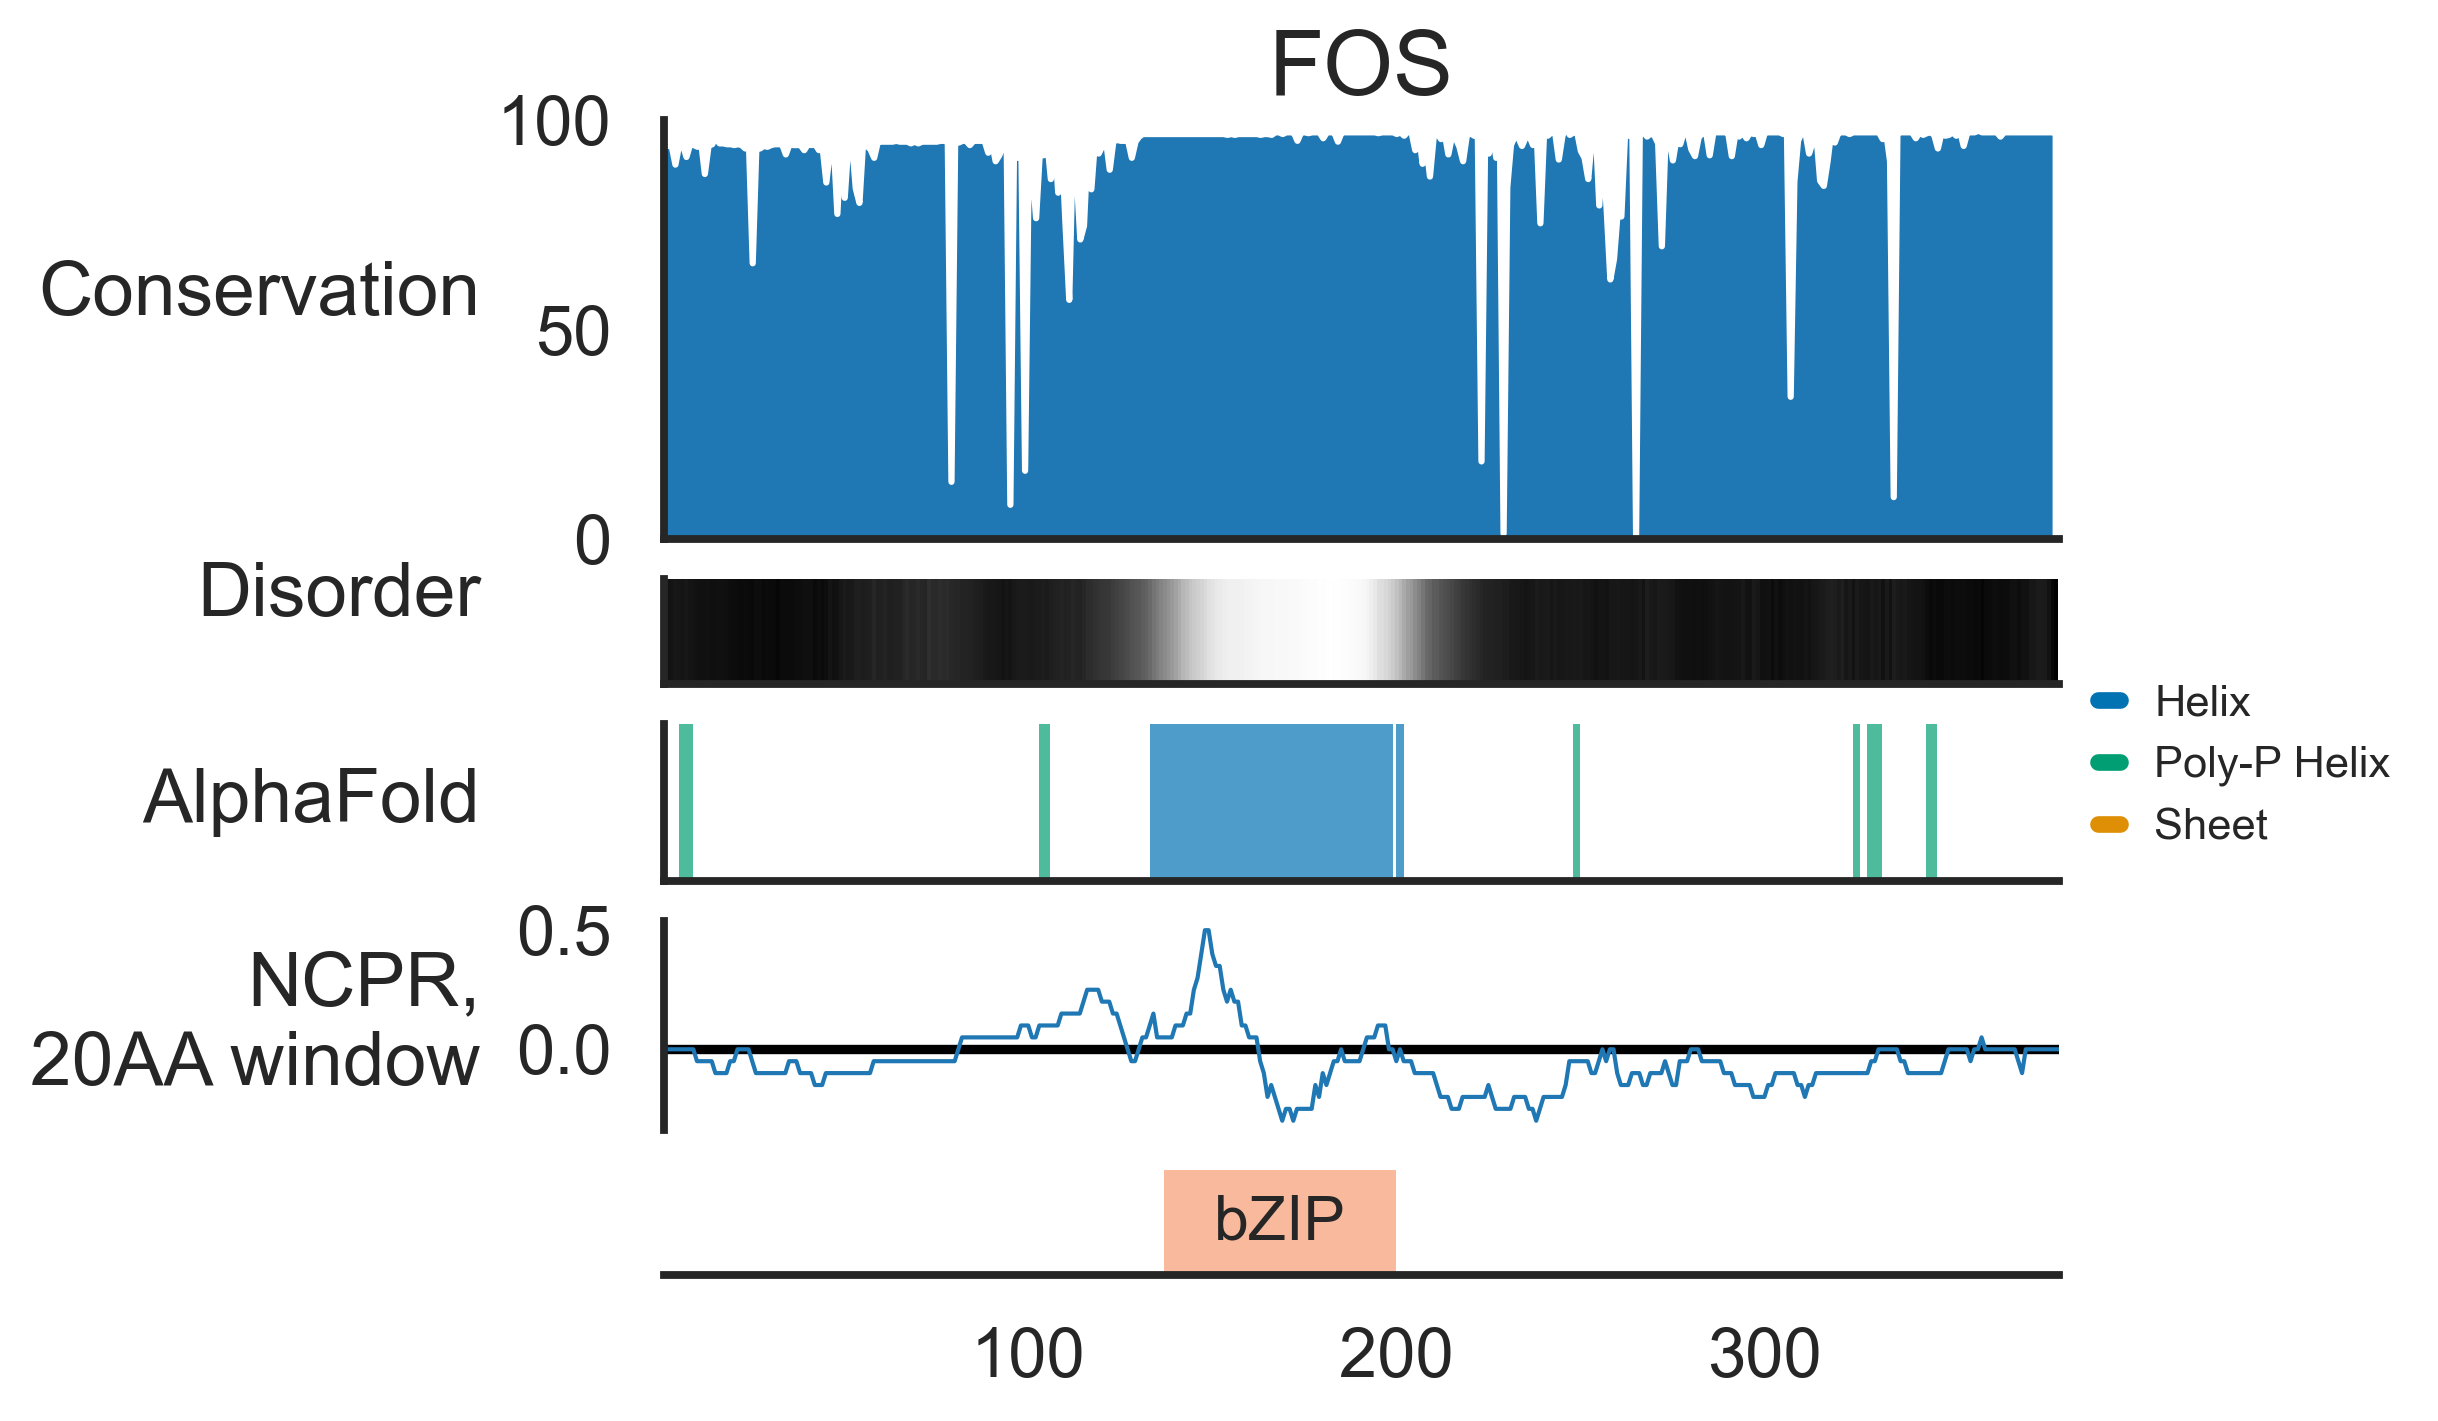

In [76]:
plot_conservation(fos_percent_identities_df, fos_ref_seq, "P01100", "FOS", bzip_start=137, bzip_end=200)

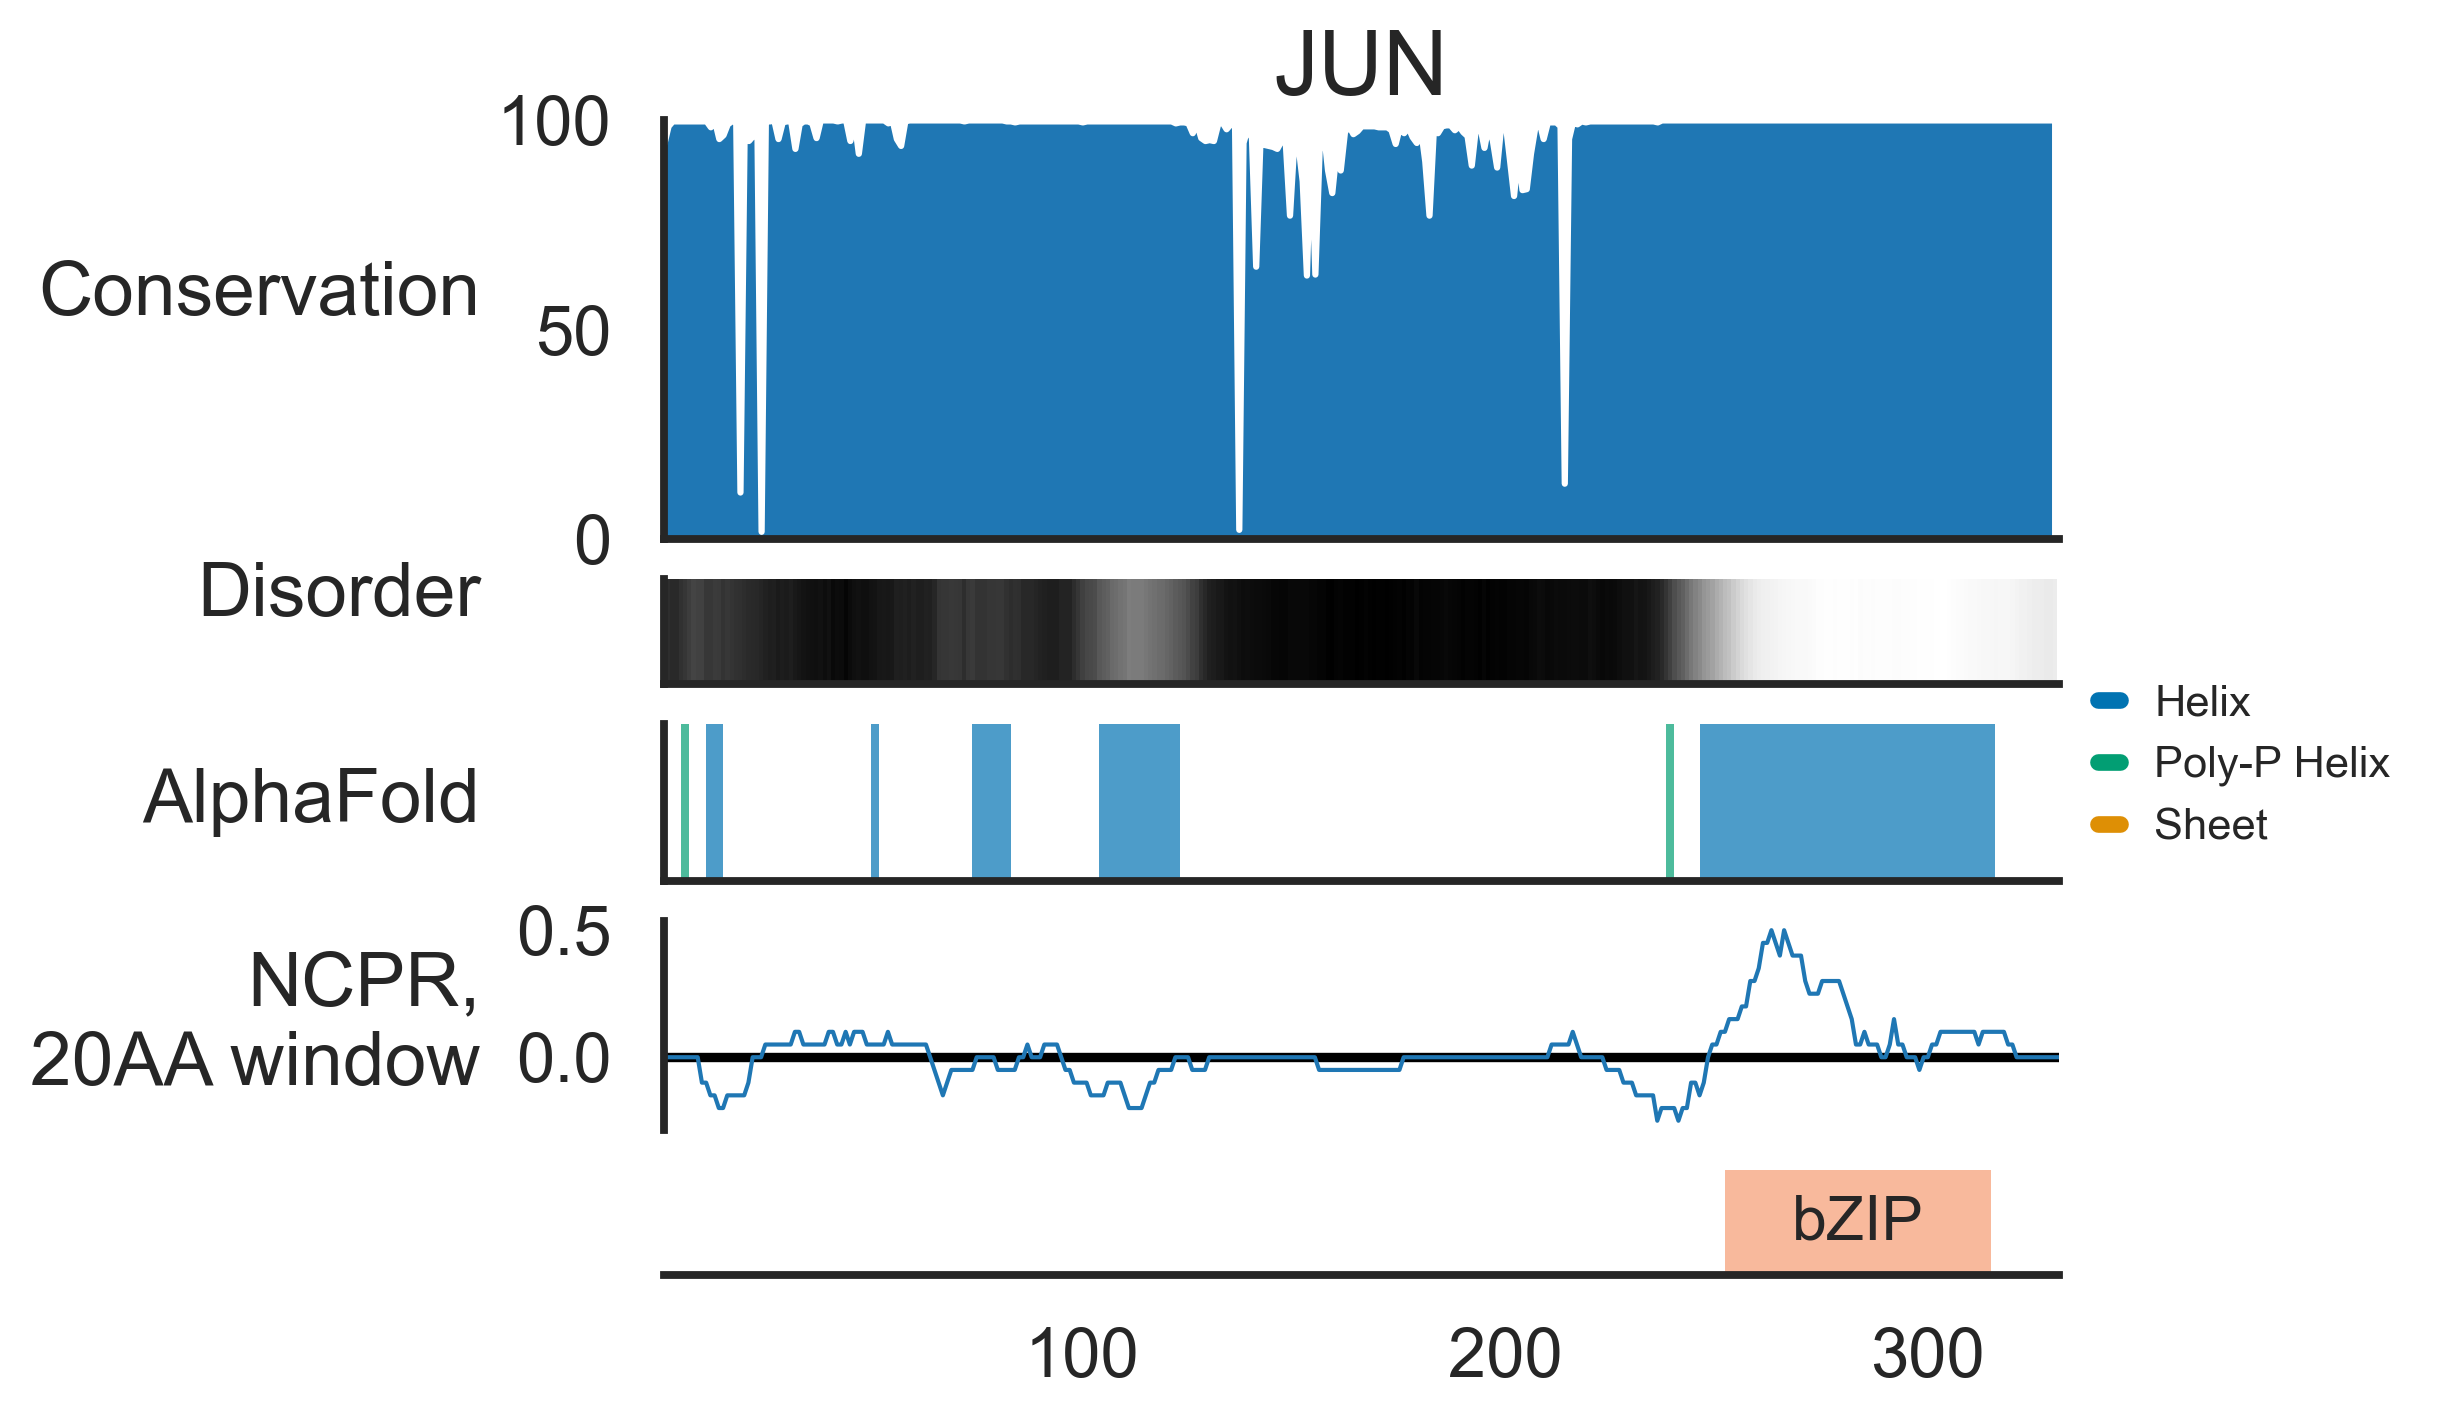

In [77]:
plot_conservation(jun_percent_identities_df, jun_ref_seq, "P05412", "JUN", bzip_start=252, bzip_end=315)